# Tasa de cancelación de clientes en Telecom

## Condiciones de la asignación principal

Al operador de telecomunicaciones Interconnect le gustaría poder pronosticar su tasa de cancelación de clientes. Si se descubre que un usuario o usuaria planea irse, se le ofrecerán códigos promocionales y opciones de planes especiales. El equipo de marketing de Interconnect ha recopilado algunos de los datos personales de sus clientes, incluyendo información sobre sus planes y contratos.

#### Servicios de Interconnect

Interconnect proporciona principalmente dos tipos de servicios:

1. Comunicación por teléfono fijo. El teléfono se puede conectar a varias líneas de manera simultánea.
2. Internet. La red se puede configurar a través de una línea telefónica (DSL, *línea de abonado digital*) o a través de un cable de fibra óptica.

Algunos otros servicios que ofrece la empresa incluyen:

- Seguridad en Internet: software antivirus (*ProtecciónDeDispositivo*) y un bloqueador de sitios web maliciosos (*SeguridadEnLínea*).
- Una línea de soporte técnico (*SoporteTécnico*).
- Almacenamiento de archivos en la nube y backup de datos (*BackupOnline*).
- Streaming de TV (*StreamingTV*) y directorio de películas (*StreamingPelículas*)

La clientela puede elegir entre un pago mensual o firmar un contrato de 1 o 2 años. Puede utilizar varios métodos de pago y recibir una factura electrónica después de una transacción.

### Inicialización

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Leer bases de datos y asignar a variables

df_con=pd.read_csv("/datasets/final_provider/contract.csv")
df_per=pd.read_csv("/datasets/final_provider/personal.csv")
df_int=pd.read_csv("/datasets/final_provider/internet.csv")
df_pho=pd.read_csv("/datasets/final_provider/phone.csv")

### EDA

In [3]:
# Descripción de los datos del dataframe contract
df_con.info()
print(df_con.describe())
print(df_con.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
       MonthlyCharges
count     7043.000000
mean        64.761692
std         30.090047
min         18.250000
25%         35.500000
50%         70.350000
75%         89.850000
max        118.750000
   customerID   BeginDate              EndDate            Type  \
0  7590-VHVEG  2020-01-01                   No  Month-to-month   
1  5575-GNVDE  2017-04-01               

In [4]:
# Descripción de los datos del dataframe personal
df_per.info()
print(df_per.describe())
print(df_per.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB
       SeniorCitizen
count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
   customerID  gender  SeniorCitizen Partner Dependents
0  7590-VHVEG  Female              0     Yes         No
1  5575-GNVDE    Male              0      No         No
2  3668-QPYBK    Male              0      No         No
3  7795-CFOCW    Male              0      No         No
4  9237-HQITU  Female              0      No         No


In [5]:
# Descripción de los datos del dataframe internet
df_int.info()
print(df_int.describe())
print(df_int.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB
        customerID InternetService OnlineSecurity OnlineBackup  \
count         5517            5517           5517         5517   
unique        5517               2              2            2   
top     6598-KELSS     Fiber optic             No           No   
freq             1            3096           3498         3088   

       DeviceProtection TechSupport StreamingTV StreamingMovi

In [6]:
# Descripción de los datos del dataframe phone
df_pho.info()
print(df_pho.describe())
print(df_pho.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB
        customerID MultipleLines
count         6361          6361
unique        6361             2
top     9231-ZJYAM            No
freq             1          3390
   customerID MultipleLines
0  5575-GNVDE            No
1  3668-QPYBK            No
2  9237-HQITU            No
3  9305-CDSKC           Yes
4  1452-KIOVK           Yes


### Transformación de datos

In [7]:
# Se unen tablas mediante outer merge en costumerID para identificar valores nulos

#Se realiza copia de dataframe de contratos
df=df_con.copy()
df= df.merge(df_per, on='customerID', how='outer')
df= df.merge(df_int, on='customerID', how='outer')
df= df.merge(df_pho, on='customerID', how='outer')
print(df.head())

   customerID   BeginDate              EndDate            Type  \
0  7590-VHVEG  2020-01-01                   No  Month-to-month   
1  5575-GNVDE  2017-04-01                   No        One year   
2  3668-QPYBK  2019-10-01  2019-12-01 00:00:00  Month-to-month   
3  7795-CFOCW  2016-05-01                   No        One year   
4  9237-HQITU  2019-09-01  2019-11-01 00:00:00  Month-to-month   

  PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges  \
0              Yes           Electronic check           29.85        29.85   
1               No               Mailed check           56.95       1889.5   
2              Yes               Mailed check           53.85       108.15   
3               No  Bank transfer (automatic)           42.30      1840.75   
4              Yes           Electronic check           70.70       151.65   

   gender  SeniorCitizen Partner Dependents InternetService OnlineSecurity  \
0  Female              0     Yes         No             

In [8]:
# Descripción de dataframe universal
print(df.describe())
df.info()

       MonthlyCharges  SeniorCitizen
count     7043.000000    7043.000000
mean        64.761692       0.162147
std         30.090047       0.368612
min         18.250000       0.000000
25%         35.500000       0.000000
50%         70.350000       0.000000
75%         89.850000       0.000000
max        118.750000       1.000000
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int6

In [9]:
# Se modifican nombres de columnas a minusculas
df.columns=df.columns.str.lower()
print(df.columns)


Index(['customerid', 'begindate', 'enddate', 'type', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'gender',
       'seniorcitizen', 'partner', 'dependents', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'multiplelines'],
      dtype='object')


In [10]:
# Se genera columna isenddate para validar si existe fecha final
df['isenddate']=df['enddate']!='No'
df['enddate']=df['enddate'].replace('No', np.nan)
print(df.head())

   customerid   begindate              enddate            type  \
0  7590-VHVEG  2020-01-01                  NaN  Month-to-month   
1  5575-GNVDE  2017-04-01                  NaN        One year   
2  3668-QPYBK  2019-10-01  2019-12-01 00:00:00  Month-to-month   
3  7795-CFOCW  2016-05-01                  NaN        One year   
4  9237-HQITU  2019-09-01  2019-11-01 00:00:00  Month-to-month   

  paperlessbilling              paymentmethod  monthlycharges totalcharges  \
0              Yes           Electronic check           29.85        29.85   
1               No               Mailed check           56.95       1889.5   
2              Yes               Mailed check           53.85       108.15   
3               No  Bank transfer (automatic)           42.30      1840.75   
4              Yes           Electronic check           70.70       151.65   

   gender  seniorcitizen  ... dependents internetservice onlinesecurity  \
0  Female              0  ...         No             DSL   

In [11]:
# begindate y enddate a DateTime
df["begindate"]=pd.to_datetime(df["begindate"])
df["enddate"]=pd.to_datetime(df["enddate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   object        
 1   begindate         7043 non-null   datetime64[ns]
 2   enddate           1869 non-null   datetime64[ns]
 3   type              7043 non-null   object        
 4   paperlessbilling  7043 non-null   object        
 5   paymentmethod     7043 non-null   object        
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7043 non-null   object        
 8   gender            7043 non-null   object        
 9   seniorcitizen     7043 non-null   int64         
 10  partner           7043 non-null   object        
 11  dependents        7043 non-null   object        
 12  internetservice   5517 non-null   object        
 13  onlinesecurity    5517 non-null   object        
 14  onlinebackup      5517 n

In [12]:
#Pasamos valores vacios de totalcharges a nan y convertimos a float
df['totalcharges']=df['totalcharges'].replace(' ', np.nan)
df['totalcharges']=df['totalcharges'].astype('float')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   object        
 1   begindate         7043 non-null   datetime64[ns]
 2   enddate           1869 non-null   datetime64[ns]
 3   type              7043 non-null   object        
 4   paperlessbilling  7043 non-null   object        
 5   paymentmethod     7043 non-null   object        
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7032 non-null   float64       
 8   gender            7043 non-null   object        
 9   seniorcitizen     7043 non-null   int64         
 10  partner           7043 non-null   object        
 11  dependents        7043 non-null   object        
 12  internetservice   5517 non-null   object        
 13  onlinesecurity    5517 non-null   object        
 14  onlinebackup      5517 n

In [13]:
#Validamos filas con totalcharges nan para verificar patrones
print(df[pd.isnull(df['totalcharges'])])

      customerid  begindate enddate      type paperlessbilling  \
488   4472-LVYGI 2020-02-01     NaT  Two year              Yes   
753   3115-CZMZD 2020-02-01     NaT  Two year               No   
936   5709-LVOEQ 2020-02-01     NaT  Two year               No   
1082  4367-NUYAO 2020-02-01     NaT  Two year               No   
1340  1371-DWPAZ 2020-02-01     NaT  Two year               No   
3331  7644-OMVMY 2020-02-01     NaT  Two year               No   
3826  3213-VVOLG 2020-02-01     NaT  Two year               No   
4380  2520-SGTTA 2020-02-01     NaT  Two year               No   
5218  2923-ARZLG 2020-02-01     NaT  One year              Yes   
6670  4075-WKNIU 2020-02-01     NaT  Two year               No   
6754  2775-SEFEE 2020-02-01     NaT  Two year              Yes   

                  paymentmethod  monthlycharges  totalcharges  gender  \
488   Bank transfer (automatic)           52.55           NaN  Female   
753                Mailed check           20.25           NaN

In [14]:
#Validamos que todos los contratos iniciados en feb-2020 no tienen totalcharges
print(df[df['begindate']=='2020-02-01'])

      customerid  begindate enddate      type paperlessbilling  \
488   4472-LVYGI 2020-02-01     NaT  Two year              Yes   
753   3115-CZMZD 2020-02-01     NaT  Two year               No   
936   5709-LVOEQ 2020-02-01     NaT  Two year               No   
1082  4367-NUYAO 2020-02-01     NaT  Two year               No   
1340  1371-DWPAZ 2020-02-01     NaT  Two year               No   
3331  7644-OMVMY 2020-02-01     NaT  Two year               No   
3826  3213-VVOLG 2020-02-01     NaT  Two year               No   
4380  2520-SGTTA 2020-02-01     NaT  Two year               No   
5218  2923-ARZLG 2020-02-01     NaT  One year              Yes   
6670  4075-WKNIU 2020-02-01     NaT  Two year               No   
6754  2775-SEFEE 2020-02-01     NaT  Two year              Yes   

                  paymentmethod  monthlycharges  totalcharges  gender  \
488   Bank transfer (automatic)           52.55           NaN  Female   
753                Mailed check           20.25           NaN

In [15]:
# Llenamos valores nulos de totalcharges con cero
df['totalcharges'].fillna(0,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   object        
 1   begindate         7043 non-null   datetime64[ns]
 2   enddate           1869 non-null   datetime64[ns]
 3   type              7043 non-null   object        
 4   paperlessbilling  7043 non-null   object        
 5   paymentmethod     7043 non-null   object        
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   seniorcitizen     7043 non-null   int64         
 10  partner           7043 non-null   object        
 11  dependents        7043 non-null   object        
 12  internetservice   5517 non-null   object        
 13  onlinesecurity    5517 non-null   object        
 14  onlinebackup      5517 n

In [16]:
#Se llena el resto de valores nulos en columnas categóricas con "unkonwn"
for colscat in df:
    if df[colscat].dtype == 'object':
        df[colscat].fillna('unknown',inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   object        
 1   begindate         7043 non-null   datetime64[ns]
 2   enddate           1869 non-null   datetime64[ns]
 3   type              7043 non-null   object        
 4   paperlessbilling  7043 non-null   object        
 5   paymentmethod     7043 non-null   object        
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7043 non-null   float64       
 8   gender            7043 non-null   object        
 9   seniorcitizen     7043 non-null   int64         
 10  partner           7043 non-null   object        
 11  dependents        7043 non-null   object        
 12  internetservice   7043 non-null   object        
 13  onlinesecurity    7043 non-null   object        
 14  onlinebackup      7043 n

In [17]:
#Verificar si todos los clientes con multiplelines unknown tienen internet y viceversa.
df_lines=df[df['multiplelines']=='unknown'].groupby('internetservice').count()
df_internet=df[df['internetservice']=='unknown'].groupby('multiplelines').count()
print(df_lines)
print(df_internet)

                 customerid  begindate  enddate  type  paperlessbilling  \
internetservice                                                           
DSL                     682        682      170   682               682   

                 paymentmethod  monthlycharges  totalcharges  gender  \
internetservice                                                        
DSL                        682             682           682     682   

                 seniorcitizen  partner  dependents  onlinesecurity  \
internetservice                                                       
DSL                        682      682         682             682   

                 onlinebackup  deviceprotection  techsupport  streamingtv  \
internetservice                                                             
DSL                       682               682          682          682   

                 streamingmovies  multiplelines  isenddate  
internetservice                                   

Se concluye que 'unknown' en datos de multiplelines y servicios de internet deberían ser "no" y en binario -1

In [18]:
# Pasamos datos a binario y/n a 1/0/-1
mapping = {'Yes': 1, 'No': 0, 'unknown': -1}
columns= ["paperlessbilling",
          "partner",
          "dependents",
          "onlinesecurity",
          "onlinebackup",
          "deviceprotection",
          "techsupport",
          "streamingtv",
          "streamingmovies",
          "multiplelines"]
for col in columns:
    df[col]= df[col].map(mapping)

mapping_gen = {'Female': 1, 'Male': 0}
mapping_int = {'DSL': 1, 'Fiber optic': 0, 'unknown': -1}
mapping_isend = {True: 1, False: 0}
df["gender"]= df["gender"].map(mapping_gen)
df["internetservice"]= df["internetservice"].map(mapping_int)
df["isenddate"]= df["isenddate"].map(mapping_isend)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerid        7043 non-null   object        
 1   begindate         7043 non-null   datetime64[ns]
 2   enddate           1869 non-null   datetime64[ns]
 3   type              7043 non-null   object        
 4   paperlessbilling  7043 non-null   int64         
 5   paymentmethod     7043 non-null   object        
 6   monthlycharges    7043 non-null   float64       
 7   totalcharges      7043 non-null   float64       
 8   gender            7043 non-null   int64         
 9   seniorcitizen     7043 non-null   int64         
 10  partner           7043 non-null   int64         
 11  dependents        7043 non-null   int64         
 12  internetservice   7043 non-null   int64         
 13  onlinesecurity    7043 non-null   int64         
 14  onlinebackup      7043 n

### Visualización

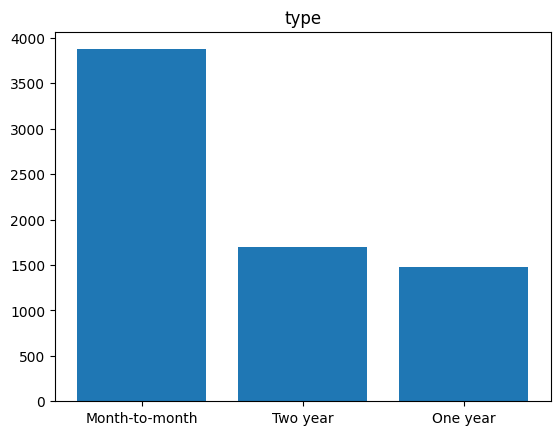

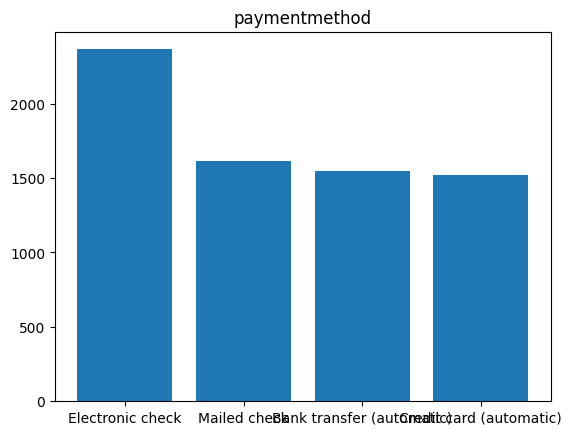

In [19]:
# Visualización de distribución de columnas categóricas
df_vis=df.drop('customerid',axis=1)
for colscat in df_vis:
    if df_vis[colscat].dtype == 'object':
        counts = df_vis[colscat].value_counts()
        plt.bar(counts.index, counts.values)
        plt.title(colscat)   
        plt.show()

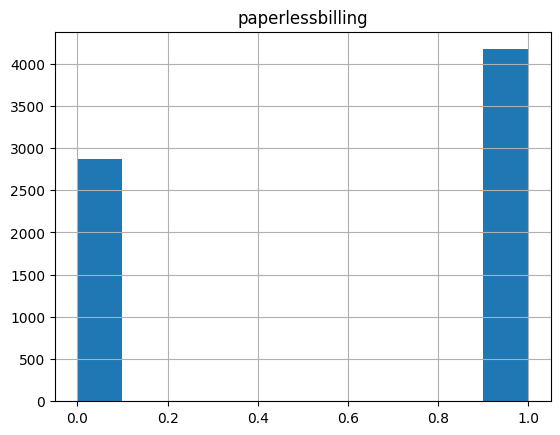

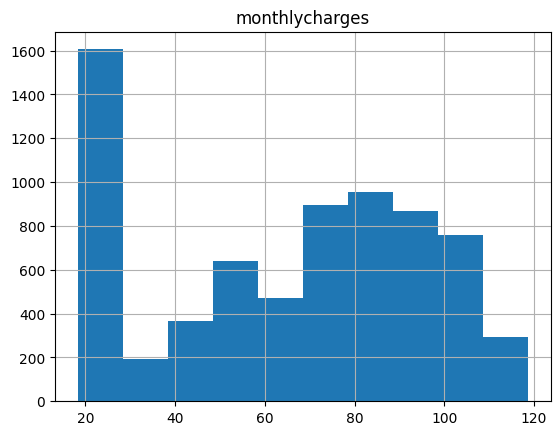

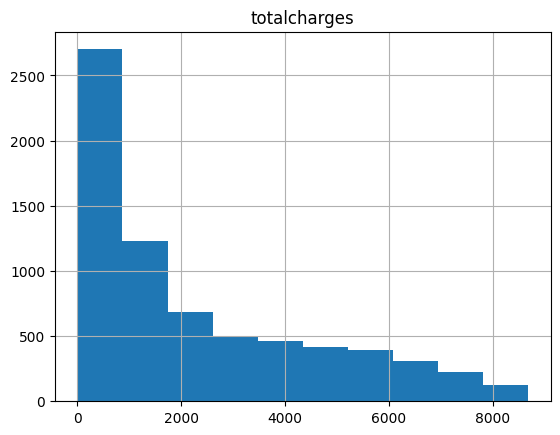

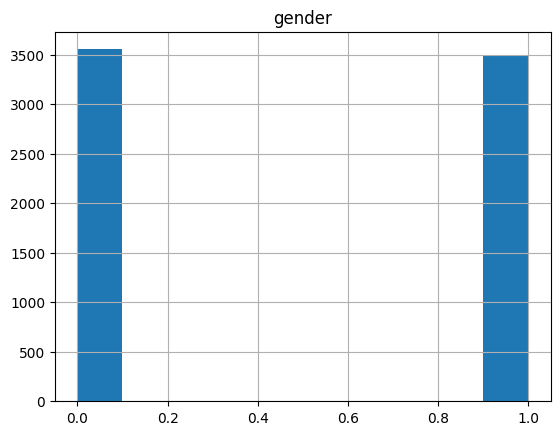

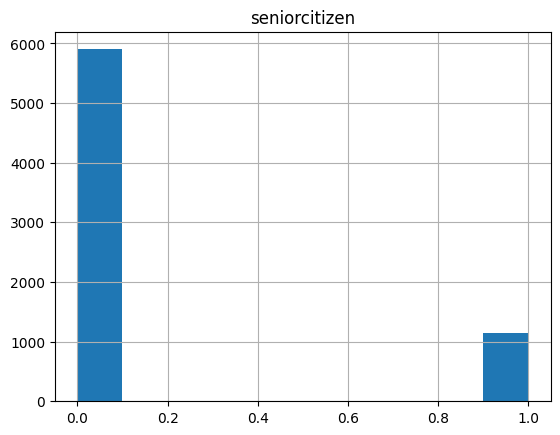

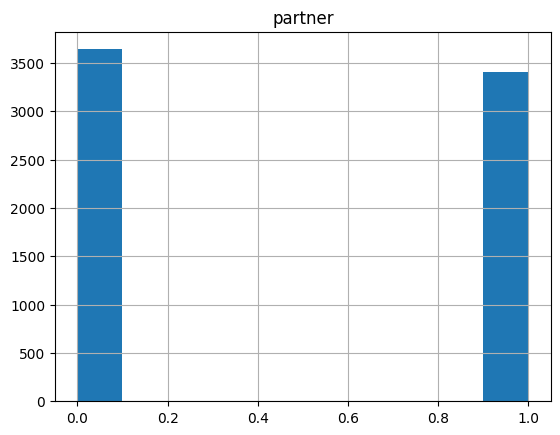

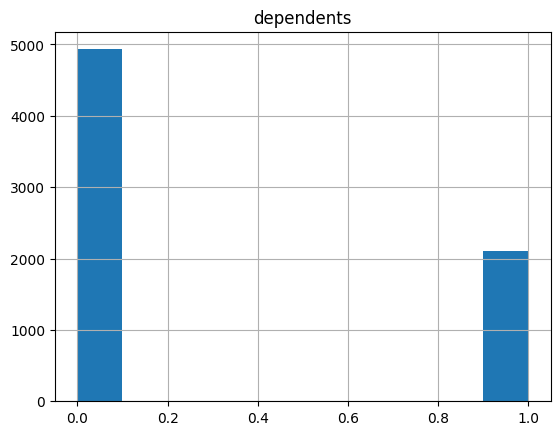

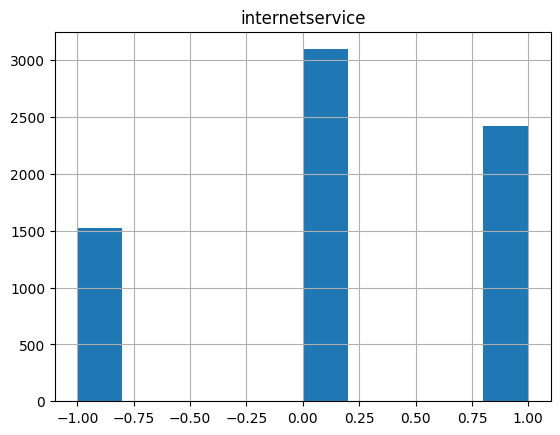

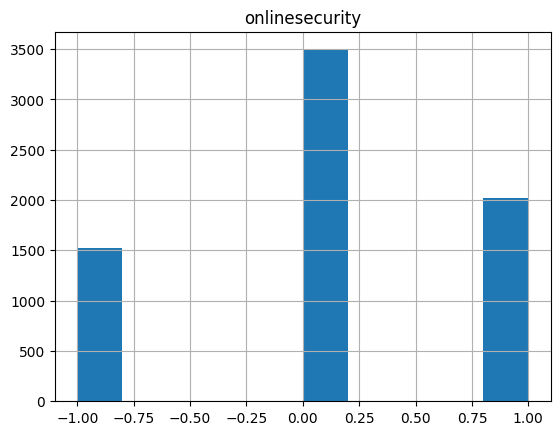

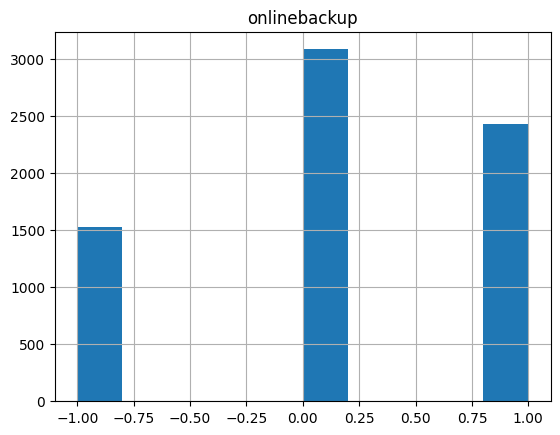

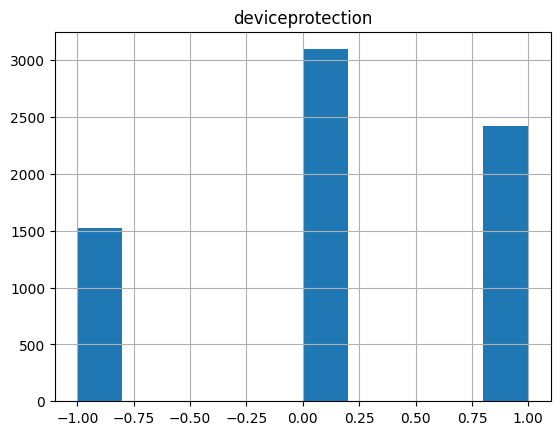

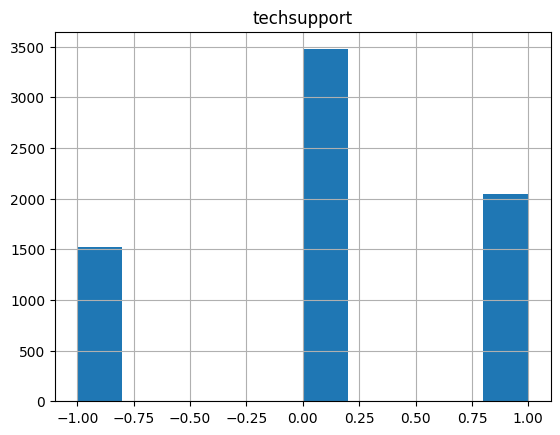

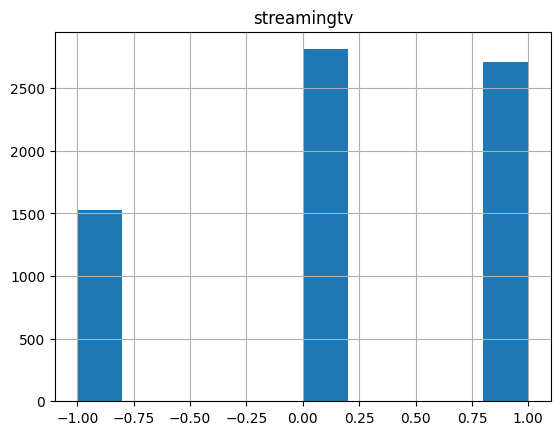

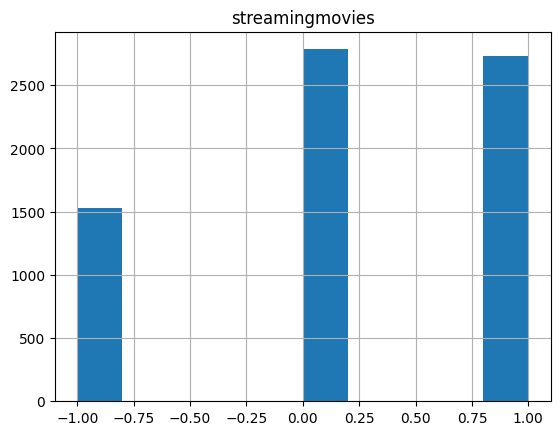

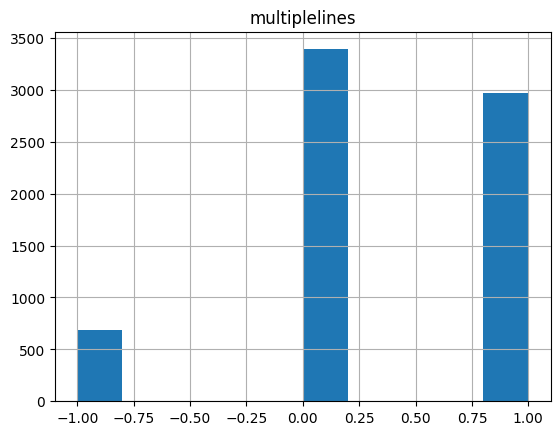

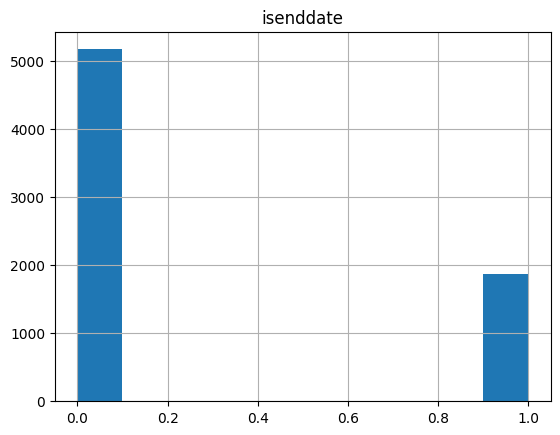

In [20]:
#Revisamos distribución de datos numéricos
for colsnum in df_vis:
    if (df_vis[colsnum].dtype == 'int64') or (df_vis[colsnum].dtype == 'float64'):
        df_vis[colsnum].hist()
        plt.title(colsnum)
        plt.show()

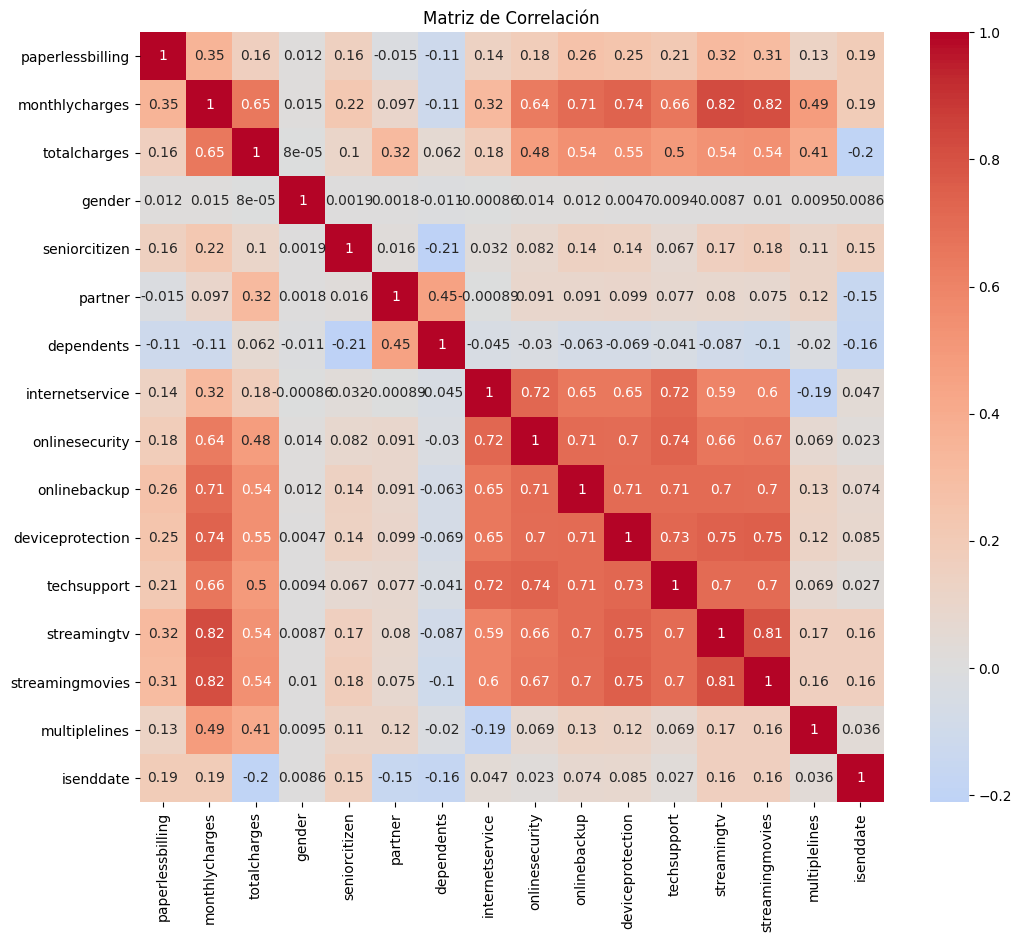

In [21]:
df_heat=df.drop(['customerid','begindate','enddate','paymentmethod','type'],axis=1)
# Crear matriz de correlación
correlation_matrix = df_heat.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

Concluimos que hay una alta correlación entre los servicios adicionales de internet y el monthlycharge y totalcharge. Podemos observar que el género es una variable que tiene una correlación bajísima con todas las variables. Por lo que se podría omitir en los futuros modelos para predecir la tasa de cancelación. Además de el servicio de internet, si cuenta con online security, tech support y multiple lines. Porque la correlación es menor al 5%

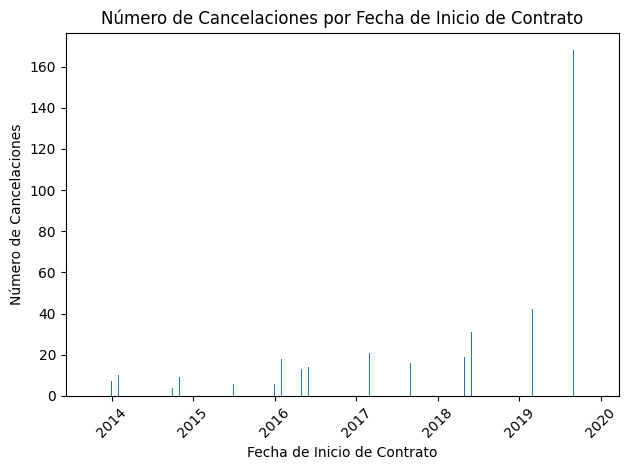

2013-10-01      3
2013-11-01      2
2013-12-01      3
2014-01-01      7
2014-02-01     10
             ... 
2019-08-01     76
2019-09-01    168
2019-10-01    144
2019-11-01    131
2019-12-01    105
Name: begindate, Length: 75, dtype: int64


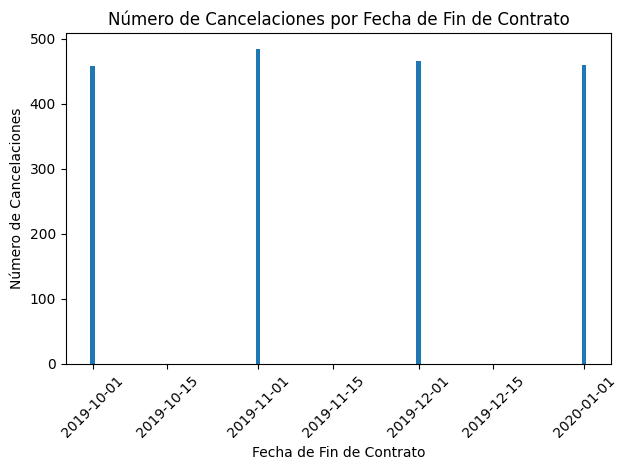

2019-10-01    458
2019-11-01    485
2019-12-01    466
2020-01-01    460
Name: enddate, dtype: int64


In [22]:
cancels = df[df['isenddate'] == 1]

# Contar cancelaciones por fecha de inicio
cancels_by_date = cancels['begindate'].value_counts().sort_index()

# Crear el gráfico de barras
plt.bar(cancels_by_date.index, cancels_by_date.values)
plt.title('Número de Cancelaciones por Fecha de Inicio de Contrato')
plt.xlabel('Fecha de Inicio de Contrato')
plt.ylabel('Número de Cancelaciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(cancels_by_date)

# Contar cancelaciones por fecha de fin
cancel_date = cancels['enddate'].value_counts().sort_index()

# Crear el gráfico de barras
plt.bar(cancel_date.index, cancel_date.values)
plt.title('Número de Cancelaciones por Fecha de Fin de Contrato')
plt.xlabel('Fecha de Fin de Contrato')
plt.ylabel('Número de Cancelaciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(cancel_date)

La mayoría de las cancelaciones son de contratos iniciados entre sep y dic de 2019. Todas las cancelaciones se realizaron entre Oct 2019 y enero 2020

### Plan de trabajo

1. Realizar EDA y transformación de datos (Done)
2. Generar un conjunto de entrenamiento y prueba. No generaremos uno de validación, ya que el conjunto de datos no es muy grande.
3. Generar al menos 3 modelos de clasificación binaria.
4. Validar los modelos con validación cruzada en métricas de exactitud y AUC-ROC
5. Realizar la evaluación final con el conjunto de prueba con las mismas métricas

### Inicialización ML

In [154]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score

### Datasets de entrenamiento y prueba

In [146]:
# Dataset de entrenamiento y prueba DT y RF
encoder = OrdinalEncoder()
data_ordinal = pd.DataFrame(encoder.fit_transform(df), columns=df.columns)
features = data_ordinal.drop(['isenddate','enddate','customerid','begindate'], axis=1)
target = data_ordinal['isenddate']

features_train, features_test, target_train, target_test = train_test_split(
features,target, test_size=.1, random_state=12345)

# Dataset de entrenamiento y prueba OHE
features_ohe = pd.get_dummies(features, drop_first=True)
features_train_ohe, features_test_ohe, target_train_ohe, target_test_ohe = train_test_split(
features_ohe,target, test_size=.1, random_state=12345)



print(features_train.shape)
print(features_test.shape)
print(target_train.shape)
print(target_test.shape)
print()
print(features_train_ohe.shape)
print(features_test_ohe.shape)
print(target_train_ohe.shape)
print(target_test_ohe.shape)


(6338, 17)
(705, 17)
(6338,)
(705,)

(6338, 17)
(705, 17)
(6338,)
(705,)


In [147]:
# Evaluación del desbalance de clases
print("Distribución de clases:")
print(target_train.value_counts())
print("Porcentaje de cancelaciones:", target_train.mean() * 100, "%")


Distribución de clases:
0.0    4659
1.0    1679
Name: isenddate, dtype: int64
Porcentaje de cancelaciones: 26.491006626696116 %


Concluimos que el desbalance de clases no es extremo, por lo que podemos usar class_weight='balanced' en los modelos para coompensar y no cambiar el tamaño del dataset artificialmente

### Selección de modelos

In [244]:
#Selección de modelos
#Regresión logística
model_lr=LogisticRegression(random_state=12345, solver='liblinear',
                            class_weight='balanced')
#Decision Tree
model_dt=DecisionTreeClassifier(random_state=12345,max_depth=6,
                                class_weight='balanced')
#Random Forest
model_rf=RandomForestClassifier(random_state=12345,max_depth=6, 
                                n_estimators=90,class_weight='balanced')
#CatBoostClassifier
model_cat=CatBoostClassifier(loss_function="Logloss", iterations=250,
                             learning_rate=0.05, max_depth=4, l2_leaf_reg=2,
                             min_data_in_leaf=20, subsample=0.7, colsample_bylevel=0.7,
                             scale_pos_weight=2.77, early_stopping_rounds=50, 
                             random_seed=12345, verbose=False)
#XGBClassifier
model_xgb = XGBClassifier(objective='binary:logistic', n_estimators=100, 
                          learning_rate=0.05,max_depth=3, min_child_weight=3,
                          subsample=0.7,colsample_bytree=0.7, scale_pos_weight=2.77,
                          reg_alpha=0.5, reg_lambda=2.5, random_state=12345,
                          eval_metric='auc', use_label_encoder=False )

In [237]:
#Regresión logística
lr_scores=cross_validate(model_lr,features_train_ohe,target_train_ohe,cv=5,
                         scoring=('roc_auc', 'accuracy'),return_train_score=True)

# Extraer las métricas de validación cruzada
test_accuracy_lr = lr_scores['test_accuracy'].mean()
test_roc_auc_lr = lr_scores['test_roc_auc'].mean()
train_accuracy_lr = lr_scores['train_accuracy'].mean()
train_roc_auc_lr = lr_scores['train_roc_auc'].mean()

print('Exactitud de la prueba',test_accuracy_lr)
print('AUC_ROC de la prueba', test_roc_auc_lr)
print('Exactitud del entrenamiento',train_accuracy_lr)
print('AUC_ROC del entrenamiento',train_roc_auc_lr)

Exactitud de la prueba 0.7439255152014621
AUC_ROC de la prueba 0.8391348836496737
Exactitud del entrenamiento 0.7466471489464982
AUC_ROC del entrenamiento 0.8420119096111327


In [238]:
#Decision tree
dt_scores=cross_validate(model_dt,features_train,target_train,cv=5,
                         scoring=('roc_auc', 'accuracy'),return_train_score=True)

# Extraer las métricas de validación cruzada
test_accuracy_dt = dt_scores['test_accuracy'].mean()
test_roc_auc_dt = dt_scores['test_roc_auc'].mean()
train_accuracy_dt = dt_scores['train_accuracy'].mean()
train_roc_auc_dt = dt_scores['train_roc_auc'].mean()

print('Exactitud de la prueba',test_accuracy_dt)
print('AUC_ROC de la prueba', test_roc_auc_dt)
print('Exactitud del entrenamiento',train_accuracy_dt)
print('AUC_ROC del entrenamiento',train_roc_auc_dt)

Exactitud de la prueba 0.7234128159864954
AUC_ROC de la prueba 0.819123687141207
Exactitud del entrenamiento 0.7561138188803798
AUC_ROC del entrenamiento 0.8635877958464706


In [239]:
#Random Forest
rf_scores=cross_validate(model_rf,features_train,target_train,cv=5,
                         scoring=('roc_auc', 'accuracy'),return_train_score=True)

# Extraer las métricas de validación cruzada
test_accuracy_rf = rf_scores['test_accuracy'].mean()
test_roc_auc_rf = rf_scores['test_roc_auc'].mean()
train_accuracy_rf = rf_scores['train_accuracy'].mean()
train_roc_auc_rf = rf_scores['train_roc_auc'].mean()

print('Exactitud de la prueba',test_accuracy_rf)
print('AUC_ROC de la prueba', test_roc_auc_rf)
print('Exactitud del entrenamiento',train_accuracy_rf)
print('AUC_ROC del entrenamiento',train_roc_auc_rf)

Exactitud de la prueba 0.7429791429617143
AUC_ROC de la prueba 0.8410423438546761
Exactitud del entrenamiento 0.7576914558826789
AUC_ROC del entrenamiento 0.867955466862473


In [240]:
#CatClassifier
cat_scores=cross_validate(model_cat,features_train,target_train,cv=5,
                         scoring=('roc_auc', 'accuracy'),return_train_score=True)

# Extraer las métricas de validación cruzada
test_accuracy_cat = cat_scores['test_accuracy'].mean()
test_roc_auc_cat = cat_scores['test_roc_auc'].mean()
train_accuracy_cat = cat_scores['train_accuracy'].mean()
train_roc_auc_cat = cat_scores['train_roc_auc'].mean()

print('Exactitud de la prueba',test_accuracy_cat)
print('AUC_ROC de la prueba', test_roc_auc_cat)
print('Exactitud del entrenamiento',train_accuracy_cat)
print('AUC_ROC del entrenamiento',train_roc_auc_cat)

Exactitud de la prueba 0.750709841424762
AUC_ROC de la prueba 0.846595694553327
Exactitud del entrenamiento 0.7745741360258298
AUC_ROC del entrenamiento 0.8761516532522572


In [245]:
#XGBClassifier
xgb_scores=cross_validate(model_xgb,features_train,target_train,cv=5,
                         scoring=('roc_auc', 'accuracy'),return_train_score=True)

# Extraer las métricas de validación cruzada
test_accuracy_xgb = xgb_scores['test_accuracy'].mean()
test_roc_auc_xgb = xgb_scores['test_roc_auc'].mean()
train_accuracy_xgb = xgb_scores['train_accuracy'].mean()
train_roc_auc_xgb = xgb_scores['train_roc_auc'].mean()

print('Exactitud de la prueba',test_accuracy_xgb)
print('AUC_ROC de la prueba', test_roc_auc_xgb)
print('Exactitud del entrenamiento',train_accuracy_xgb)
print('AUC_ROC del entrenamiento',train_roc_auc_xgb)

Exactitud de la prueba 0.7437671640453243
AUC_ROC de la prueba 0.8457758860373245
Exactitud del entrenamiento 0.7572579197875376
AUC_ROC del entrenamiento 0.8643530469159069


### Evaluación final

In [247]:
#Entrenamiento de modelo seleccionado
model_xgb.fit(features_train, target_train)
predict_test = model_xgb.predict(features_test)

print('AUC-ROC del conjunto de prueba:', roc_auc_score(target_test, predict_test))
print('Exactitud del conjunto de prueba:', accuracy_score(target_test, predict_test))

AUC-ROC del conjunto de prueba: 0.7838783852835973
Exactitud del conjunto de prueba: 0.7546099290780142


Concluimos con el modelo de XGBoost con un AUC_ROC de 78.38%, en el conjunto de prueba. El cual cumple con los requerimientos del proyecto.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
Buen trabajo Roxana! Has cumplido buena parte del flujo técnico: juntaste las fuentes, ajustaste tipos, trataste nulos, codificaste variables y entrenaste varios modelos con validación cruzada y seeds. ✅  

**Sin embargo hay decisiones que conviene revisar:** veo que usaste OrdinalEncoder sobre todo el dataframe (incluyendo columnas tipo fecha / id) — eso puede introducir codificaciones no deseadas; llenaste totalcharges con 0 en vez de imputar/derivar (p. ej. monthly * tenure) y usaste un split aleatorio en vez de uno temporal, lo que puede filtrar información futura al entrenamiento. ⚠️  

**Recomendación práctica:** añade un modelo base (DummyClassifier), evita encodificar columnas irrelevantes antes de filtrar features, crea la variable tenure desde las fechas y realiza un split temporal para la evaluación final. 🚀
</div>


### Conclusiones y recomendaciones

- Nivel general de cumplimiento: intermedio. Bien hecho Roxana, tu notebook demuestra manejo sólido de EDA, transformación y uso de modelos avanzados (XGBoost, CatBoost) con validación cruzada; aunque faltan algunos pasos que puedes mejorar... 🚀

**- Principales fortalezas:**

  - Integración y limpieza de varias tablas en un solo dataset; ajustes de tipos y tratamiento de nulos fueron realizados de forma ordenada. ✅  
  - Uso de varios algoritmos y validación cruzada con seeds, además de ajuste por desequilibrio de clases (class_weight / scale_pos_weight). ✅  
  - Visualizaciones y análisis temporal inicial que permiten interpretar cuándo ocurrieron las cancelaciones. ✅

**- Áreas de oportunidad y de mejora:**

  - 👀 Toma en cuenta que faltó partir los datos respetando la naturaleza temporal (split temporal) para evitar filtrado de información entre train/test. ⚠️  
  - **RECOMENDABLE** Añadir un modelo base (Dummy) como referencia, hacer búsqueda de hiperparámetros (Grid/RandomSearch) y calibración de umbrales para mejorar robustez. 🔁  
  - 👀 Revisar imputación de totalcharges (llenar con 0 puede sesgar) y derivar features útiles como tenure; además evita aplicar OrdinalEncoder a columnas como customerid o fechas. 💡  
  - **PARA EXPLORAR ASPECTOS AVANZADOS** Extraer e interpretar la importancia de variables (feature importance / SHAP) y documentar implicancias de negocio de las conclusiones. 📊

Buen trabajo en la estructura general y en llevar varios modelos hasta evaluación. tu proyecto queda aprobado 🥇. Con unos ajustes técnicos clave (split temporal, baseline, mejor imputación y explicación de variables) tu entregable sube de intermedio a avanzado. Sigue así — pequeños cambios te acercan mucho a un resultado reproducible y listo para negocio. 💪 ✅